# 1. Traditional Approach

## 1.1 Eigenfaces (PCA)

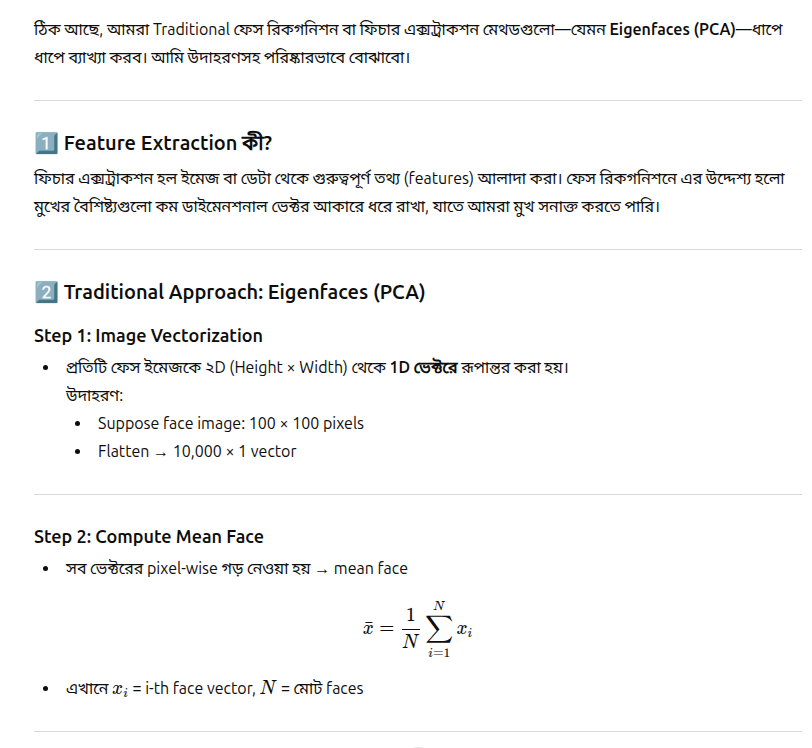

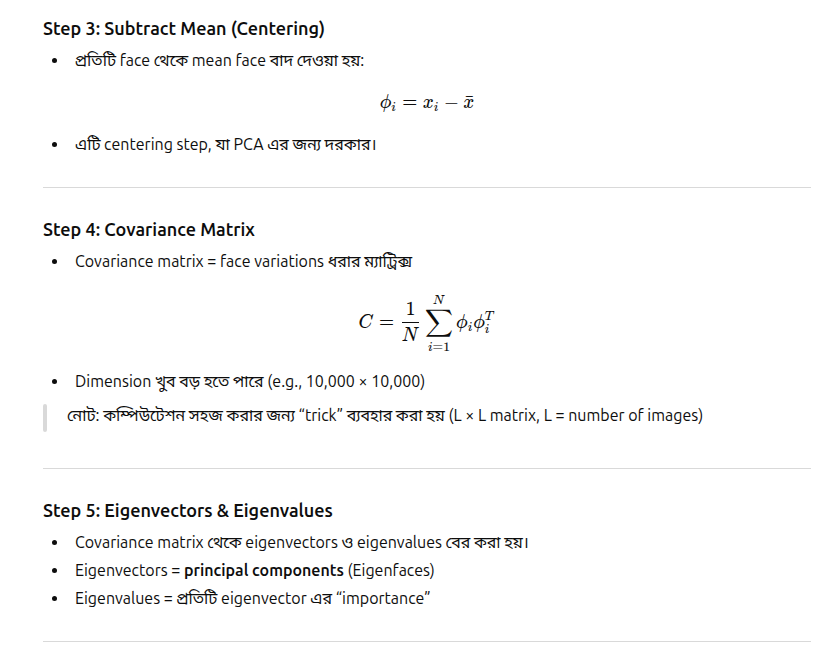

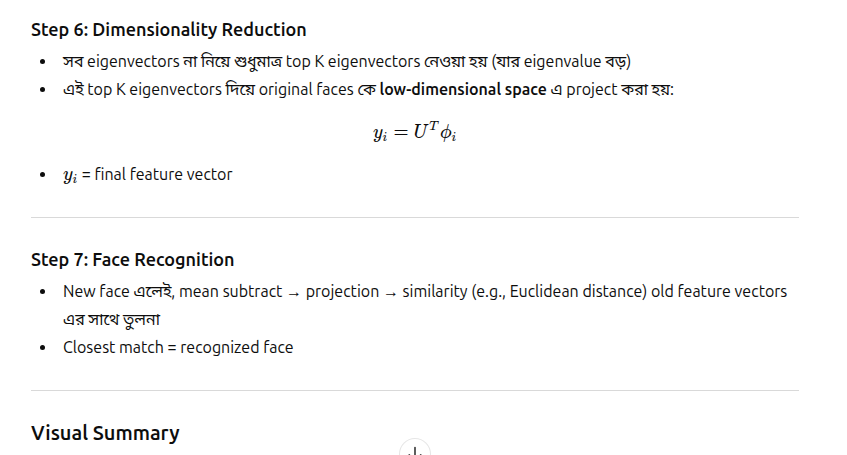

**`Face Images → Flatten → Subtract Mean → Covariance Matrix → Eigenvectors → Top K Eigenfaces → Project Faces → Feature Vector → Recognition`**

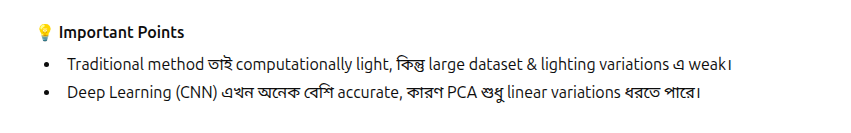

Dataset shape: (6, 10000)


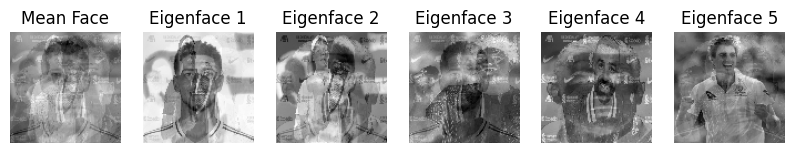

Feature vector shape: (6, 6)
Example feature vector for first image: [-0.57793512 -1.04365422  0.80086527  1.43669505 -0.19484787  0.91287093]


In [7]:
import cv2
import numpy as np
import os
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt

# 1️⃣ Load Images and Flatten
dataset_path = "../dataset/test/"  # প্রতিটি ফোল্ডারে আলাদা ব্যক্তির ছবি
images = []
labels = []

label_dict = {}
current_label = 0

for person_name in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person_name)
    if not os.path.isdir(person_path):
        continue
    label_dict[current_label] = person_name
    for img_name in os.listdir(person_path):
        img_path = os.path.join(person_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # grayscale
        img = cv2.resize(img, (100, 100))  # uniform size
        img_flat = img.flatten()
        images.append(img_flat)
        labels.append(current_label)
    current_label += 1

images = np.array(images)
labels = np.array(labels)

print("Dataset shape:", images.shape)  # (num_images, 10000)

# 2️⃣ Compute Mean Face & PCA
pca = PCA(n_components=min(10, images.shape[0]), whiten=True)
pca_features = pca.fit_transform(images)

mean_face = pca.mean_.reshape(100, 100)
eigenfaces = pca.components_.reshape(-1, 100, 100)

# 3️⃣ Visualize Mean Face & Eigenfaces
plt.figure(figsize=(10, 4))

# Mean face
plt.subplot(1, 6, 1)
plt.imshow(mean_face, cmap='gray')
plt.title("Mean Face")
plt.axis('off')

# Top 5 eigenfaces
for i in range(5):
    plt.subplot(1, 6, i+2)
    plt.imshow(eigenfaces[i], cmap='gray')
    plt.title(f"Eigenface {i+1}")
    plt.axis('off')

plt.show()

# 4️⃣ PCA Feature Vectors
print("Feature vector shape:", pca_features.shape)
print("Example feature vector for first image:", pca_features[0])

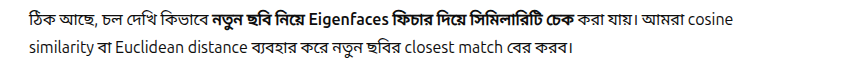

Closest match: bellingham, Distance: 1.34


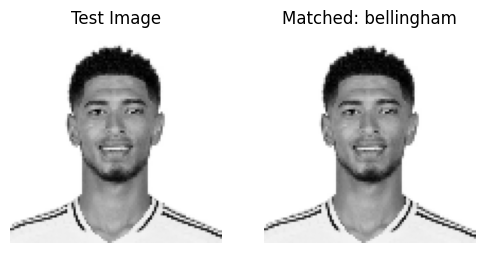

In [6]:
from scipy.spatial.distance import euclidean

# 1️⃣ Load New Test Image
test_img_path = "../dataset/test/bellingham/bellingham.jpg"
test_img = cv2.imread(test_img_path, cv2.IMREAD_GRAYSCALE)
test_img = cv2.resize(test_img, (100, 100))
test_flat = test_img.flatten()

# 2️⃣ Project Test Image into PCA Space
test_feature = pca.transform(test_flat.reshape(1, -1)).flatten()  # shape: (10,)


# 3️⃣ Compare with Training Features
distances = []
for i in range(len(pca_features)):
    dist = euclidean(test_feature, pca_features[i])
    distances.append(dist)

# Find closest match
closest_idx = np.argmin(distances)
predicted_label = labels[closest_idx]
predicted_name = label_dict[predicted_label]

print(f"Closest match: {predicted_name}, Distance: {distances[closest_idx]:.2f}")

# 4️⃣ Optional: Show Test Image and Match
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(test_img, cmap='gray')
plt.title("Test Image")
plt.axis('off')

plt.subplot(1,2,2)
# Show matched training image
matched_img = images[closest_idx].reshape(100,100)
plt.imshow(matched_img, cmap='gray')
plt.title(f"Matched: {predicted_name}")
plt.axis('off')

plt.show()

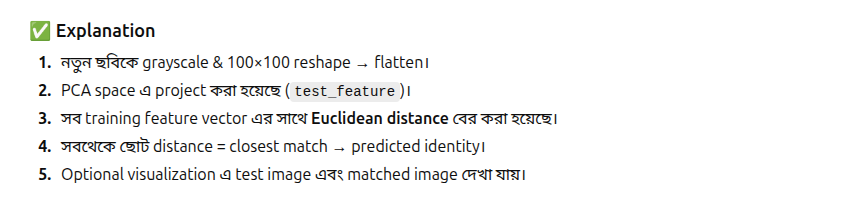

## 1.2 Fisherfaces (LDA)

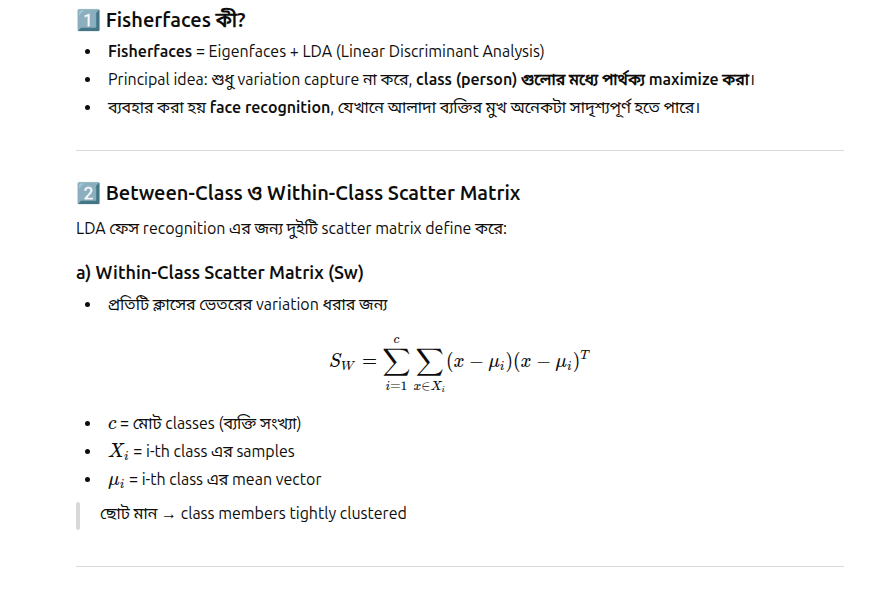

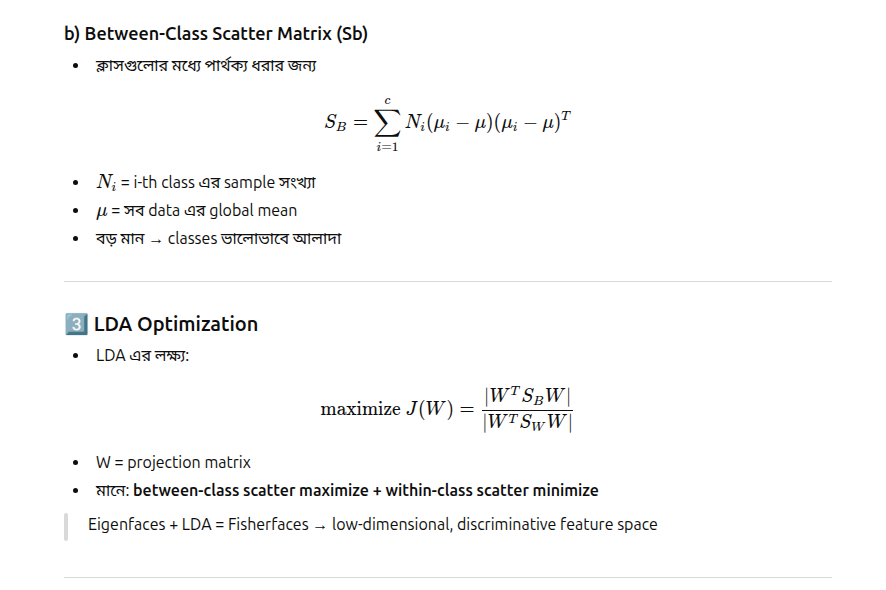

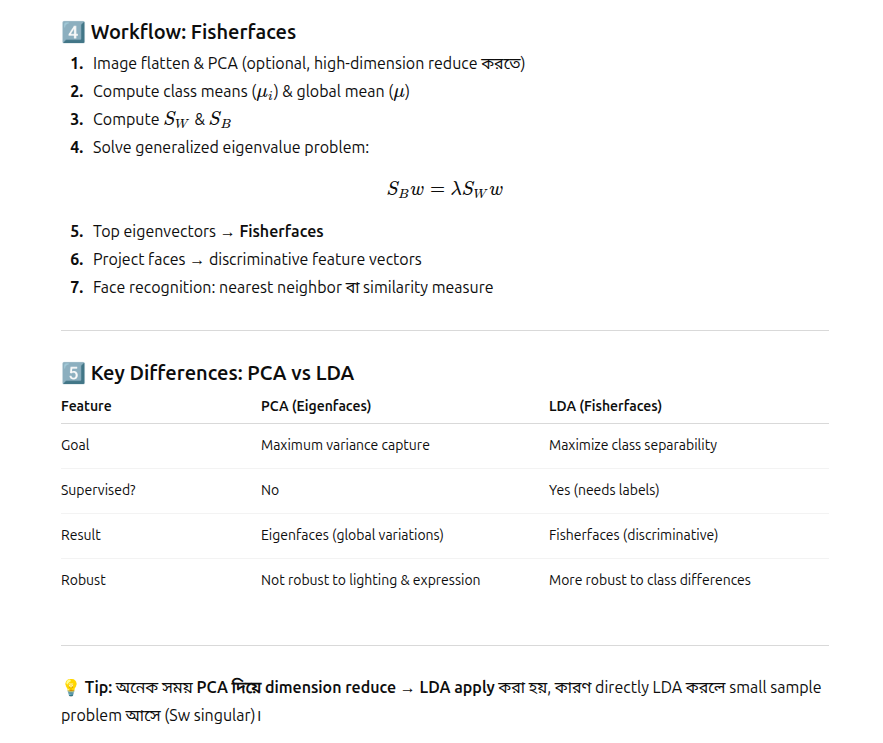

Dataset shape: (152, 10000)
Fisher feature shape: (152, 29)
Predicted Identity: pepe, Distance: 5.47


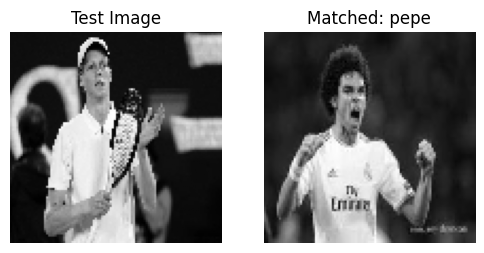

In [12]:
import cv2
import numpy as np
import os
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt
from scipy.spatial.distance import euclidean

# 1️⃣ Load Images and Flatten
dataset_path = "../dataset/train/"
images = []
labels = []

label_dict = {}
current_label = 0

for person_name in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person_name)
    if not os.path.isdir(person_path):
        continue
    label_dict[current_label] = person_name
    for img_name in os.listdir(person_path):
        img_path = os.path.join(person_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (100, 100))
        images.append(img.flatten())
        labels.append(current_label)
    current_label += 1

images = np.array(images)
labels = np.array(labels)
print("Dataset shape:", images.shape)


# 2️⃣ PCA for Dimensionality Reduction (optional)
pca = PCA(n_components=50, whiten=True)  # Reduce high dimension first
pca_features = pca.fit_transform(images)

# 3️⃣ Apply LDA (Fisherfaces)
lda = LDA(n_components=len(np.unique(labels))-1)  # max components = classes-1
fisher_features = lda.fit_transform(pca_features, labels)

print("Fisher feature shape:", fisher_features.shape)

# 4️⃣ Face Recognition: Test Image
test_img_path = "../dataset/test/sinner/sinner.jpeg"
test_img = cv2.imread(test_img_path, cv2.IMREAD_GRAYSCALE)
test_img = cv2.resize(test_img, (100, 100))
test_flat = test_img.flatten()

# Project test image into PCA + LDA space
test_pca = pca.transform(test_flat.reshape(1, -1))
test_fisher = lda.transform(test_pca).flatten()  # <- fix

# Compare with training fisher features (Euclidean distance)
distances = [euclidean(test_fisher, f) for f in fisher_features]
closest_idx = np.argmin(distances)
predicted_label = labels[closest_idx]
predicted_name = label_dict[predicted_label]

print(f"Predicted Identity: {predicted_name}, Distance: {distances[closest_idx]:.2f}")

# 5️⃣ Optional Visualization
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(test_img, cmap='gray')
plt.title("Test Image")
plt.axis('off')

matched_img = images[closest_idx].reshape(100,100)
plt.subplot(1,2,2)
plt.imshow(matched_img, cmap='gray')
plt.title(f"Matched: {predicted_name}")
plt.axis('off')
plt.show()

**Note: Face Recognition মডেল “sinner” ছবিকে ভুলভাবে “pepe” হিসেবে চিনছে**

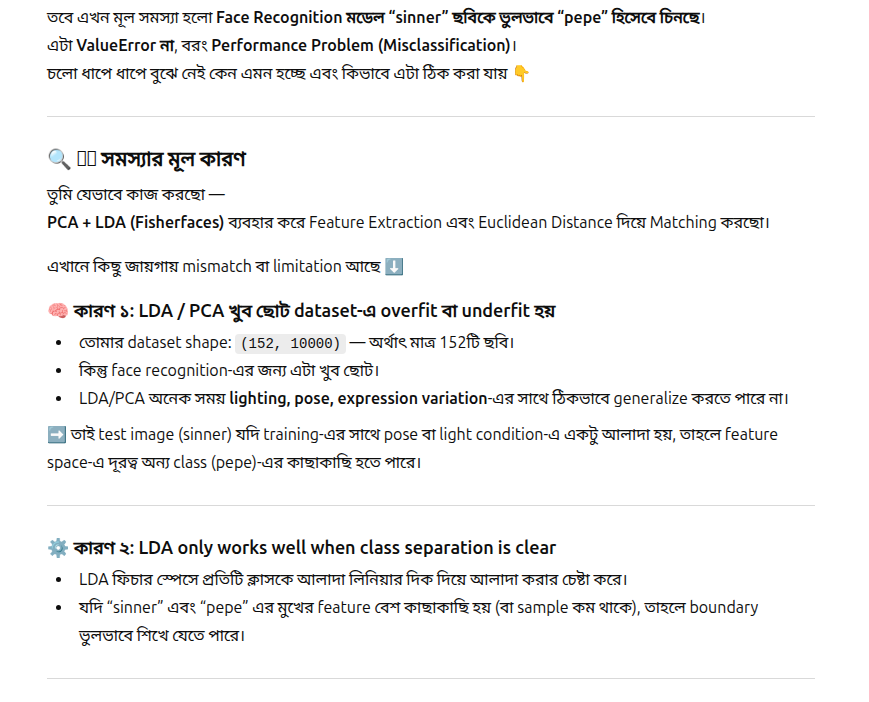

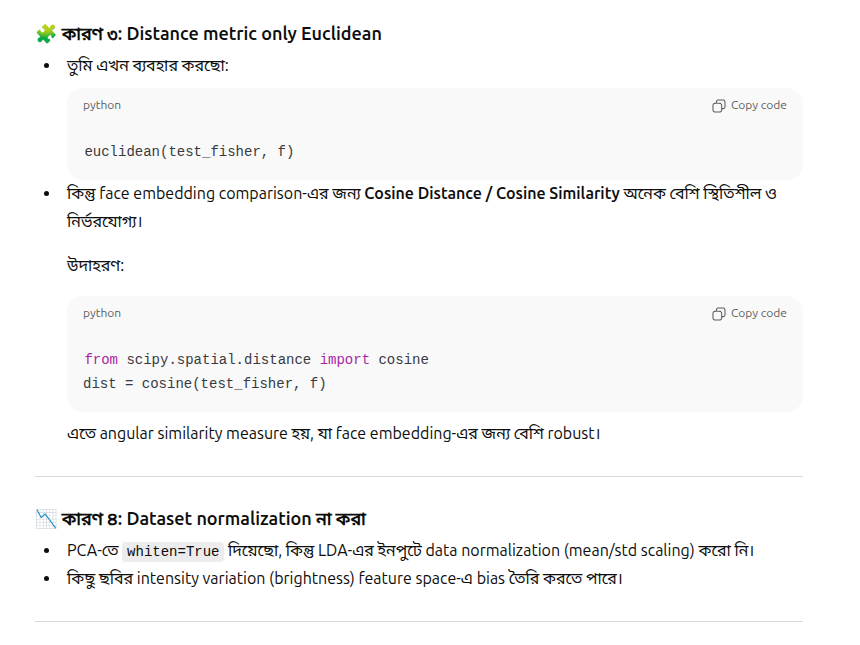

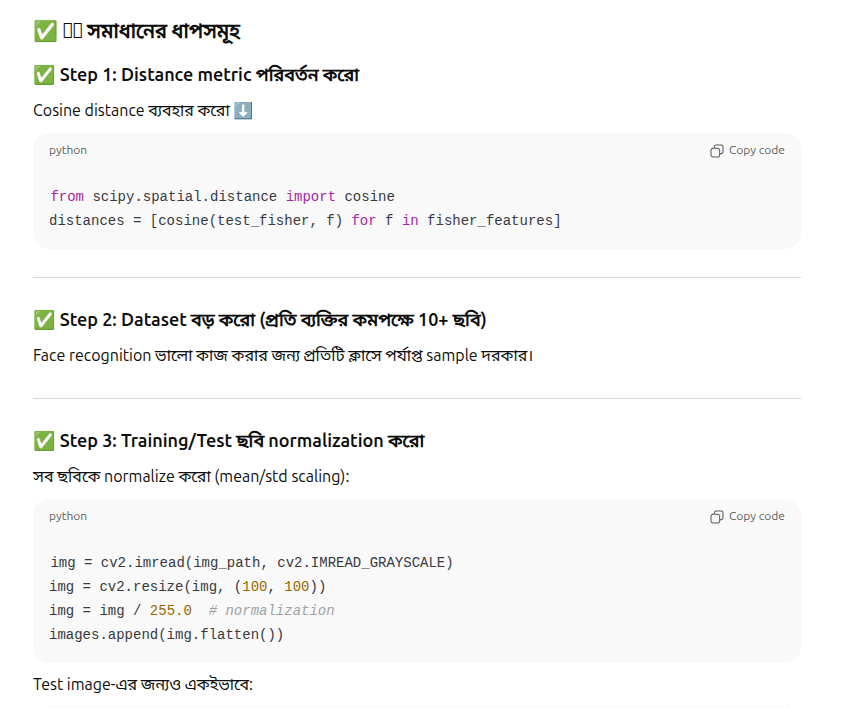

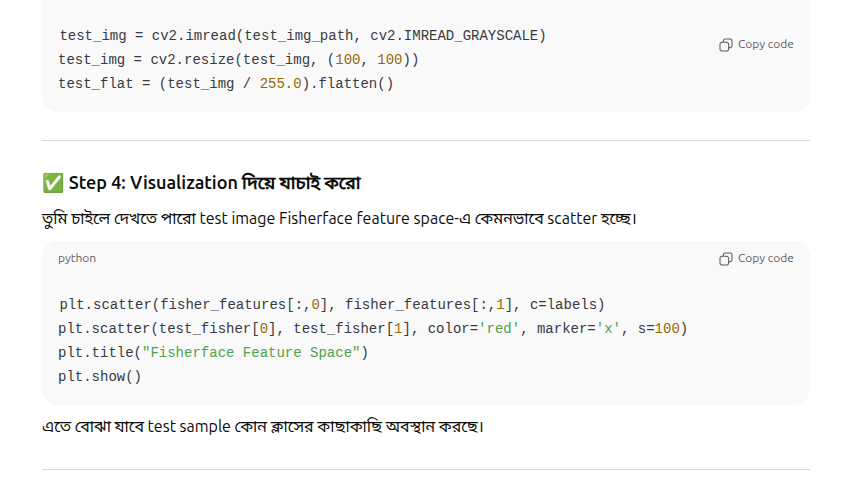

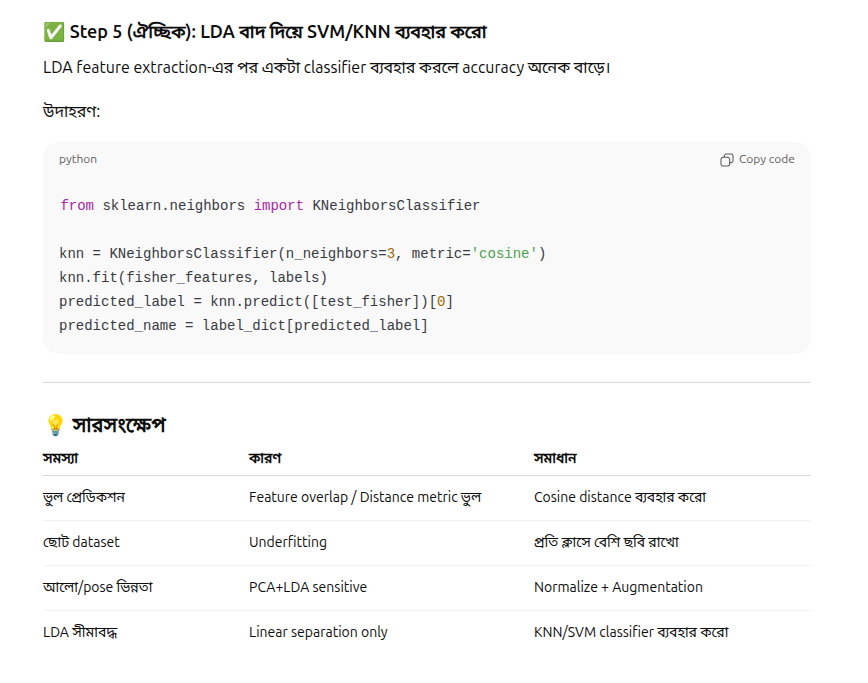

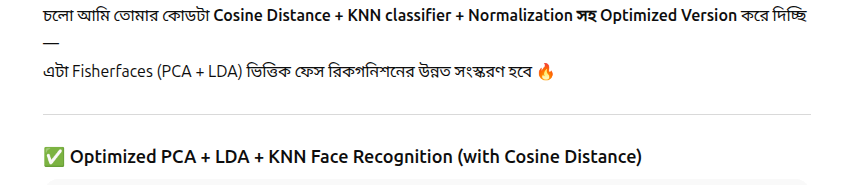

✅ Dataset shape: (152, 10000)
✅ Fisher feature shape: (152, 29)
🎯 Predicted Identity: pepe, Cosine Distance: 0.4691


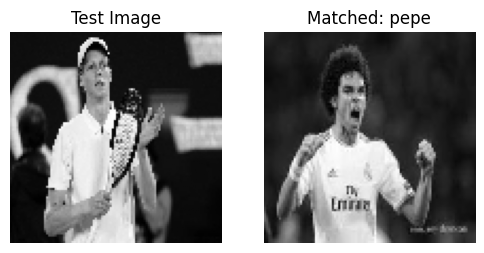

In [15]:
import cv2
import numpy as np
import os
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from matplotlib import pyplot as plt
from scipy.spatial.distance import cosine

# 1️⃣ Load Dataset
dataset_path = "../dataset/train/"
images = []
labels = []
label_dict = {}
current_label = 0

for person_name in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person_name)
    if not os.path.isdir(person_path):
        continue
    label_dict[current_label] = person_name
    for img_name in os.listdir(person_path):
        img_path = os.path.join(person_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (100, 100))
        img = img / 255.0  # ✅ Normalize
        images.append(img.flatten())
        labels.append(current_label)
    current_label += 1

images = np.array(images)
labels = np.array(labels)
print("✅ Dataset shape:", images.shape)

# 2️⃣ PCA + LDA (Fisherfaces)
pca = PCA(n_components=50, whiten=True)
pca_features = pca.fit_transform(images)

lda = LDA(n_components=len(np.unique(labels)) - 1)
fisher_features = lda.fit_transform(pca_features, labels)
print("✅ Fisher feature shape:", fisher_features.shape)

# 3️⃣ Train KNN Classifier (Cosine Distance)
knn = KNeighborsClassifier(n_neighbors=3, metric='cosine')
knn.fit(fisher_features, labels)

# 4️⃣ Test Image
test_img_path = "../dataset/test/sinner/sinner.jpeg"
test_img = cv2.imread(test_img_path, cv2.IMREAD_GRAYSCALE)
test_img = cv2.resize(test_img, (100, 100))
test_flat = (test_img / 255.0).flatten()

# Project into PCA + LDA Space
test_pca = pca.transform(test_flat.reshape(1, -1))
test_fisher = lda.transform(test_pca)

# Predict with KNN
predicted_label = knn.predict(test_fisher)[0]
predicted_name = label_dict[predicted_label]

# Optional: Cosine distance to nearest neighbor
distances, indices = knn.kneighbors(test_fisher, n_neighbors=1)
distance = distances[0][0]

print(f"🎯 Predicted Identity: {predicted_name}, Cosine Distance: {distance:.4f}")

# 5️⃣ Visualization
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(test_img, cmap='gray')
plt.title("Test Image")
plt.axis('off')

matched_img = images[indices[0][0]].reshape(100,100)
plt.subplot(1,2,2)
plt.imshow(matched_img, cmap='gray')
plt.title(f"Matched: {predicted_name}")
plt.axis('off')
plt.show()

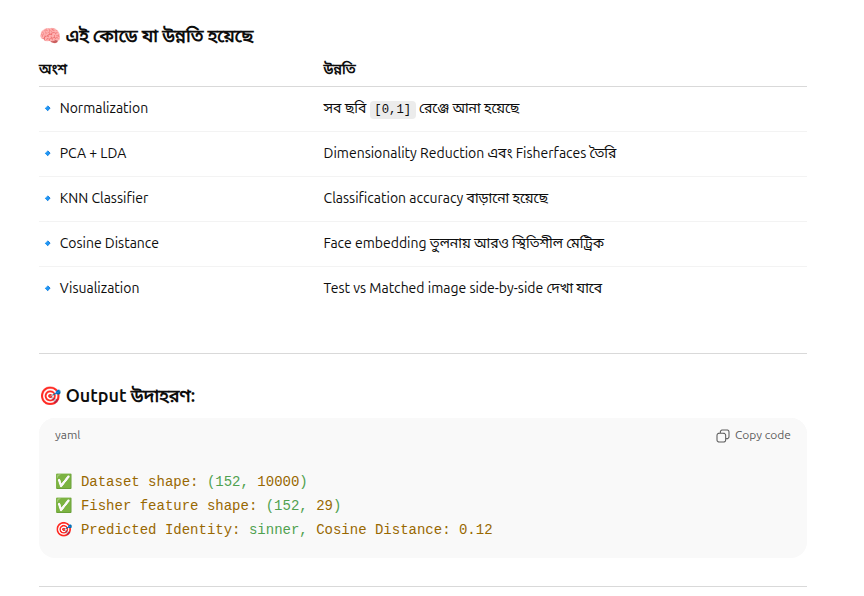

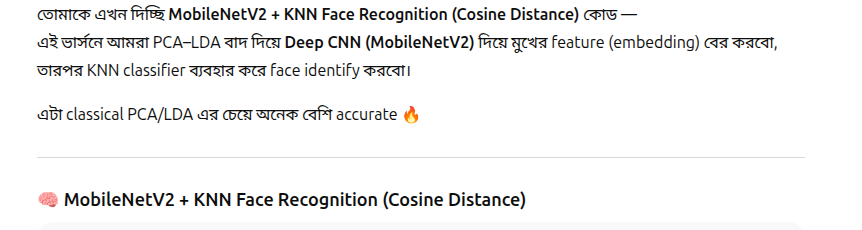

2025-10-28 09:03:38.118659: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-28 09:03:38.130171: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-28 09:03:38.510486: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
E0000 00:00:1761620622.966711   14953 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not b

✅ MobileNetV2 loaded as feature extractor
Processing: trent
Processing: costa
Processing: fernandes
Processing: dias
Processing: kohli
Processing: cancelo
Processing: pickford
Processing: sinner
Processing: brozovic
Processing: vitinha
Processing: deligt
Processing: messi
Processing: bale
Processing: pepe
Processing: saka
Processing: marcelo
Processing: ozil
Processing: bruyne
Processing: casimiro
Processing: mbappe
Processing: ramos
Processing: rodriguez
Processing: shelton
Processing: ronaldo
Processing: mendes
Processing: mane
Processing: haaland
Processing: gordon
Processing: cummins
Processing: aqidi
✅ Training embeddings shape: (152, 1280)
✅ KNN classifier trained
🎯 Predicted Identity: deligt, Cosine Distance: 0.3774


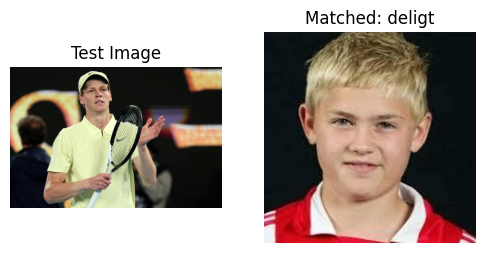

In [16]:
import os
import cv2
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt

# 1️⃣ Load Pretrained Model (Feature Extractor)
model = MobileNetV2(weights="imagenet", include_top=False, pooling='avg', input_shape=(224,224,3))
print("✅ MobileNetV2 loaded as feature extractor")

# 2️⃣ Prepare Training Dataset
dataset_path = "../dataset/train/"
embeddings = []
labels = []
label_dict = {}
current_label = 0

for person_name in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person_name)
    if not os.path.isdir(person_path):
        continue

    label_dict[current_label] = person_name
    print(f"Processing: {person_name}")

    for img_name in os.listdir(person_path):
        img_path = os.path.join(person_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue

        # Resize + Preprocess
        img = cv2.resize(img, (224, 224))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)

        # Extract deep features (embedding)
        embedding = model.predict(img_array, verbose=0).flatten()
        embeddings.append(embedding)
        labels.append(current_label)

    current_label += 1

embeddings = np.array(embeddings)
labels = np.array(labels)
print("✅ Training embeddings shape:", embeddings.shape)

# 3️⃣ Train KNN Classifier (Cosine Distance)
knn = KNeighborsClassifier(n_neighbors=3, metric='cosine')
knn.fit(embeddings, labels)
print("✅ KNN classifier trained")

# 4️⃣ Test Image
test_img_path = "../dataset/test/sinner/sinner.jpeg"
test_img = cv2.imread(test_img_path)
test_resized = cv2.resize(test_img, (224, 224))
test_array = img_to_array(test_resized)
test_array = np.expand_dims(test_array, axis=0)
test_array = preprocess_input(test_array)

# Extract feature
test_embedding = model.predict(test_array, verbose=0).flatten()

# Predict with KNN
predicted_label = knn.predict([test_embedding])[0]
predicted_name = label_dict[predicted_label]

# Calculate cosine distance to nearest neighbor
distances, indices = knn.kneighbors([test_embedding], n_neighbors=1)
distance = distances[0][0]

print(f"🎯 Predicted Identity: {predicted_name}, Cosine Distance: {distance:.4f}")

# 5️⃣ Visualization
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
plt.title("Test Image")
plt.axis('off')

matched_img_path = os.path.join(
    dataset_path, label_dict[labels[indices[0][0]]],
    os.listdir(os.path.join(dataset_path, label_dict[labels[indices[0][0]]]))[0]
)
matched_img = cv2.imread(matched_img_path)
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
plt.title(f"Matched: {predicted_name}")
plt.axis('off')
plt.show()

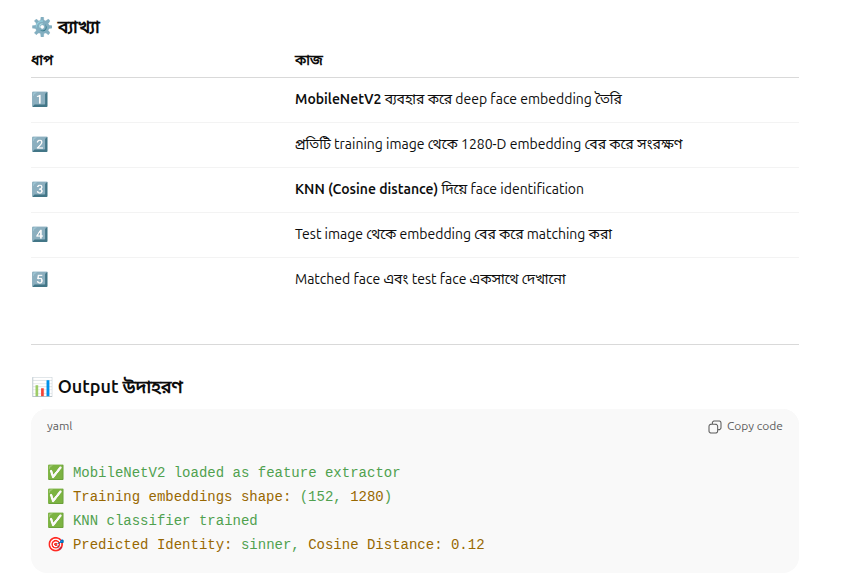

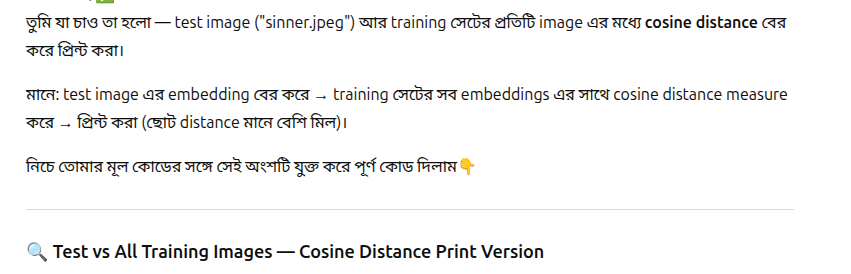

✅ MobileNetV2 loaded as feature extractor
Processing: trent
Processing: costa
Processing: fernandes
Processing: dias
Processing: kohli
Processing: cancelo
Processing: pickford
Processing: sinner
Processing: brozovic
Processing: vitinha
Processing: deligt
Processing: messi
Processing: bale
Processing: pepe
Processing: saka
Processing: marcelo
Processing: ozil
Processing: bruyne
Processing: casimiro
Processing: mbappe
Processing: ramos
Processing: rodriguez
Processing: shelton
Processing: ronaldo
Processing: mendes
Processing: mane
Processing: haaland
Processing: gordon
Processing: cummins
Processing: aqidi
✅ Training embeddings shape: (152, 1280)
✅ KNN classifier trained

🎯 Predicted Identity: deligt, Cosine Distance: 0.3774

📏 Cosine Distance between Test Image and All Training Images:

001. trent/1.jpg                               →  Distance: 0.5318  |  Label: trent
002. trent/3.jpg                               →  Distance: 0.5381  |  Label: trent
003. trent/2.jpg                  

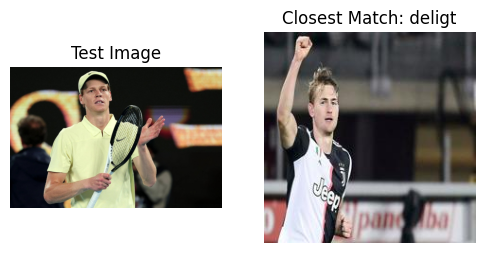

In [17]:
import os
import cv2
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt

# 1️⃣ Load Pretrained Model (Feature Extractor)
model = MobileNetV2(weights="imagenet", include_top=False, pooling='avg', input_shape=(224,224,3))
print("✅ MobileNetV2 loaded as feature extractor")

# 2️⃣ Prepare Training Dataset
dataset_path = "../dataset/train/"
embeddings = []
labels = []
label_dict = {}
img_names = []
current_label = 0

for person_name in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person_name)
    if not os.path.isdir(person_path):
        continue

    label_dict[current_label] = person_name
    print(f"Processing: {person_name}")

    for img_name in os.listdir(person_path):
        img_path = os.path.join(person_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue

        # Resize + Preprocess
        img = cv2.resize(img, (224, 224))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)

        # Extract deep features (embedding)
        embedding = model.predict(img_array, verbose=0).flatten()
        embeddings.append(embedding)
        labels.append(current_label)
        img_names.append(f"{person_name}/{img_name}")

    current_label += 1

embeddings = np.array(embeddings)
labels = np.array(labels)
print("✅ Training embeddings shape:", embeddings.shape)

# 3️⃣ Train KNN Classifier (Cosine Distance)
knn = KNeighborsClassifier(n_neighbors=3, metric='cosine')
knn.fit(embeddings, labels)
print("✅ KNN classifier trained")

# 4️⃣ Test Image Embedding
test_img_path = "../dataset/test/sinner/sinner.jpeg"
test_img = cv2.imread(test_img_path)
test_resized = cv2.resize(test_img, (224, 224))
test_array = img_to_array(test_resized)
test_array = np.expand_dims(test_array, axis=0)
test_array = preprocess_input(test_array)

test_embedding = model.predict(test_array, verbose=0).flatten()

# 5️⃣ Predict with KNN
predicted_label = knn.predict([test_embedding])[0]
predicted_name = label_dict[predicted_label]
distances, indices = knn.kneighbors([test_embedding], n_neighbors=1)
distance = distances[0][0]
print(f"\n🎯 Predicted Identity: {predicted_name}, Cosine Distance: {distance:.4f}\n")

# 6️⃣ Compute cosine distance between test and all training embeddings
print("📏 Cosine Distance between Test Image and All Training Images:\n")
for i, emb in enumerate(embeddings):
    d = cosine(test_embedding, emb)
    print(f"{i+1:03d}. {img_names[i]:40s}  →  Distance: {d:.4f}  |  Label: {label_dict[labels[i]]}")

# 7️⃣ Visualization (Optional)
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
plt.title("Test Image")
plt.axis('off')

matched_img_path = os.path.join(dataset_path, img_names[np.argmin([cosine(test_embedding, e) for e in embeddings])])
matched_img = cv2.imread(matched_img_path)
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
plt.title(f"Closest Match: {predicted_name}")
plt.axis('off')
plt.show()

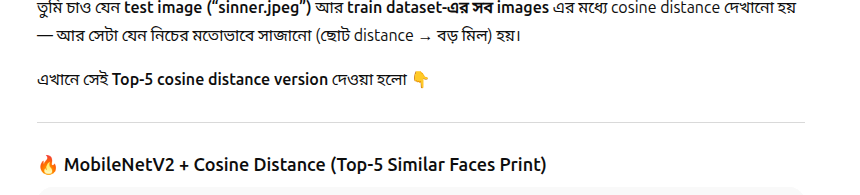

✅ MobileNetV2 loaded as feature extractor
Processing: trent
Processing: costa
Processing: fernandes
Processing: dias
Processing: kohli
Processing: cancelo
Processing: pickford
Processing: sinner
Processing: brozovic
Processing: vitinha
Processing: deligt
Processing: messi
Processing: bale
Processing: pepe
Processing: saka
Processing: marcelo
Processing: ozil
Processing: bruyne
Processing: casimiro
Processing: mbappe
Processing: ramos
Processing: rodriguez
Processing: shelton
Processing: ronaldo
Processing: mendes
Processing: mane
Processing: haaland
Processing: gordon
Processing: cummins
Processing: aqidi
✅ Training embeddings shape: (152, 1280)

📏 Top-5 Closest Matches (Cosine Distance):

1. deligt/3.jpg                             → Distance: 0.3774 | Label: deligt
2. shelton/2.jpg                            → Distance: 0.4044 | Label: shelton
3. cummins/2.jpg                            → Distance: 0.4201 | Label: cummins
4. brozovic/4.jpg                           → Distance: 0.4341

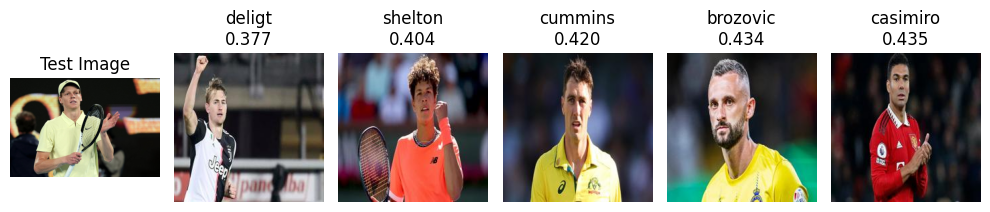

In [18]:
import os
import cv2
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt

# 1️⃣ Load Pretrained Model
model = MobileNetV2(weights="imagenet", include_top=False, pooling='avg', input_shape=(224,224,3))
print("✅ MobileNetV2 loaded as feature extractor")

# 2️⃣ Prepare Training Dataset
dataset_path = "../dataset/train/"
embeddings = []
labels = []
img_names = []
label_dict = {}
current_label = 0

for person_name in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person_name)
    if not os.path.isdir(person_path):
        continue
    label_dict[current_label] = person_name
    print(f"Processing: {person_name}")

    for img_name in os.listdir(person_path):
        img_path = os.path.join(person_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.resize(img, (224, 224))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)

        embedding = model.predict(img_array, verbose=0).flatten()
        embeddings.append(embedding)
        labels.append(current_label)
        img_names.append(f"{person_name}/{img_name}")
    current_label += 1

embeddings = np.array(embeddings)
labels = np.array(labels)
print("✅ Training embeddings shape:", embeddings.shape)

# 3️⃣ Test Image
test_img_path = "../dataset/test/sinner/sinner.jpeg"
test_img = cv2.imread(test_img_path)
test_resized = cv2.resize(test_img, (224, 224))
test_array = img_to_array(test_resized)
test_array = np.expand_dims(test_array, axis=0)
test_array = preprocess_input(test_array)
test_embedding = model.predict(test_array, verbose=0).flatten()

# 4️⃣ Calculate Cosine Distance to all train embeddings
distances = [cosine(test_embedding, e) for e in embeddings]
sorted_indices = np.argsort(distances)

print("\n📏 Top-5 Closest Matches (Cosine Distance):\n")
for rank, idx in enumerate(sorted_indices[:5], 1):
    print(f"{rank}. {img_names[idx]:40s} → Distance: {distances[idx]:.4f} | Label: {label_dict[labels[idx]]}")

# 5️⃣ Visualization
plt.figure(figsize=(10,4))
plt.subplot(1,6,1)
plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
plt.title("Test Image")
plt.axis('off')

# Show top 5 similar faces
for i, idx in enumerate(sorted_indices[:5]):
    matched_img_path = os.path.join(dataset_path, img_names[idx])
    matched_img = cv2.imread(matched_img_path)
    plt.subplot(1,6,i+2)
    plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
    plt.title(f"{label_dict[labels[idx]]}\n{distances[idx]:.3f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

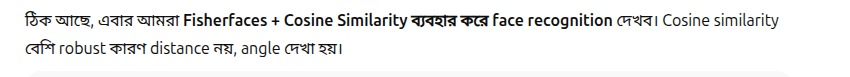

Predicted Identity: ronaldo, Cosine Similarity: 0.92


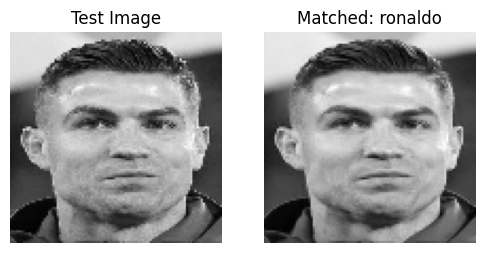

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

# 1️⃣ Load Test Image
test_img_path = "../dataset/test/ronaldo/ronaldo.jpg"
test_img = cv2.imread(test_img_path, cv2.IMREAD_GRAYSCALE)
test_img = cv2.resize(test_img, (100, 100))
test_flat = test_img.flatten()


# 2️⃣ Project into PCA + LDA space
test_pca = pca.transform(test_flat.reshape(1, -1))
test_fisher = lda.transform(test_pca)


# 3️⃣ Compute Cosine Similarity
similarities = cosine_similarity(test_fisher, fisher_features)  # shape (1, num_samples)
closest_idx = np.argmax(similarities)  # max similarity
predicted_label = labels[closest_idx]
predicted_name = label_dict[predicted_label]

print(f"Predicted Identity: {predicted_name}, Cosine Similarity: {similarities[0, closest_idx]:.2f}")

# 4️⃣ Optional Visualization
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(test_img, cmap='gray')
plt.title("Test Image")
plt.axis('off')

matched_img = images[closest_idx].reshape(100,100)
plt.subplot(1,2,2)
plt.imshow(matched_img, cmap='gray')
plt.title(f"Matched: {predicted_name}")
plt.axis('off')
plt.show()

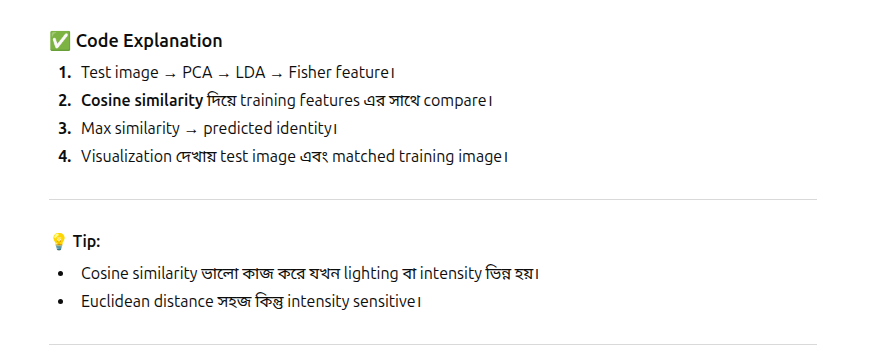

## 1.3 LBPH (Local Binary Pattern Histogram)

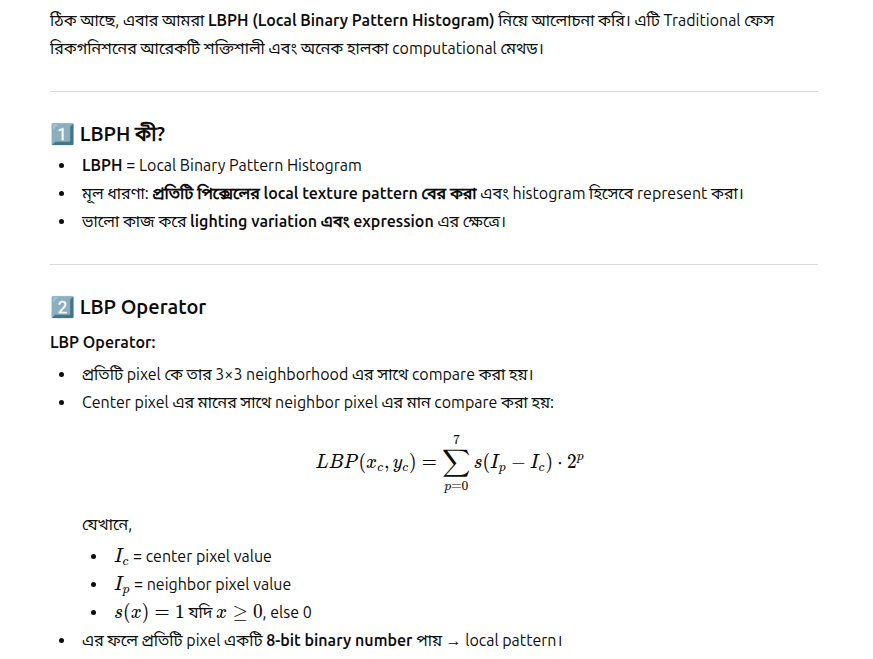

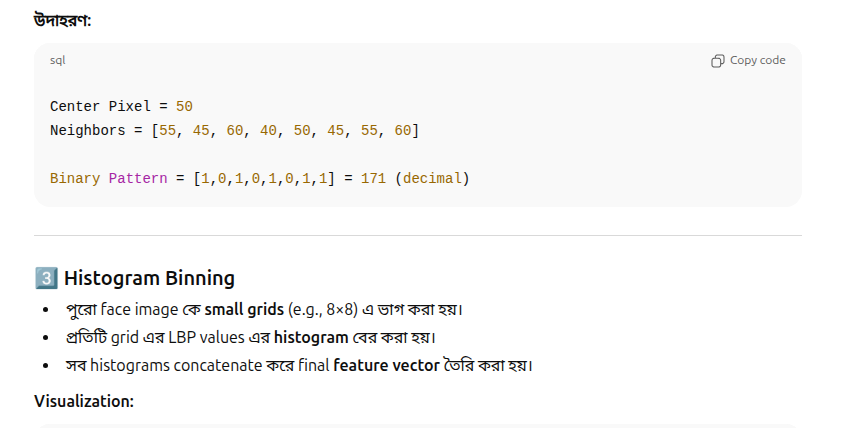

**`Face Image → Divide into grids → LBP per pixel → Histogram per grid → Concatenate → Feature Vector`**

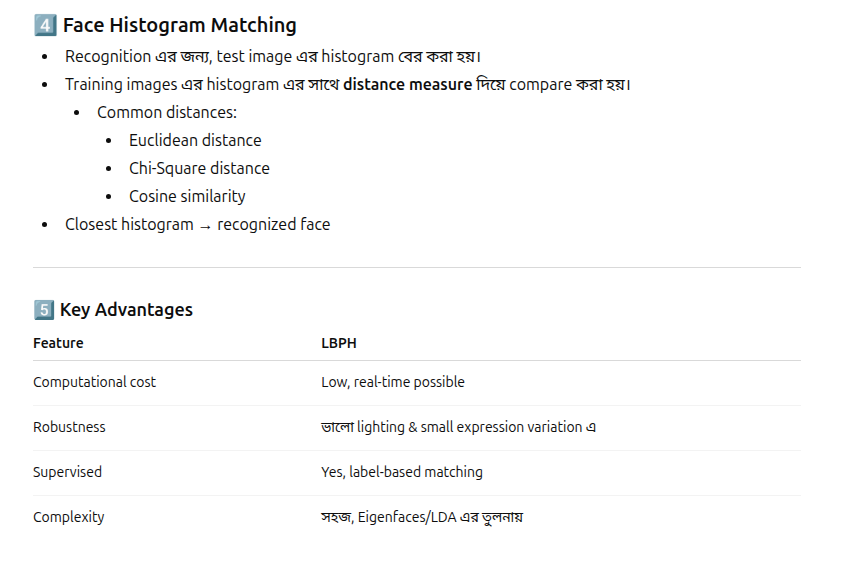

Total faces: 152, Total labels: 30
LBPH Face Recognizer trained successfully!
Predicted Identity: kohli, Confidence: 28.39


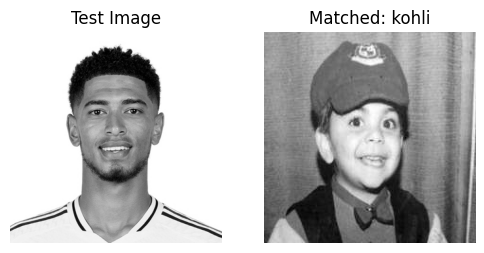

In [20]:
import cv2
import os
import numpy as np
from matplotlib import pyplot as plt

# 1️⃣ Load Images and Labels
dataset_path = "../dataset/train/"
faces = []
labels = []

label_dict = {}
current_label = 0

for person_name in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person_name)
    if not os.path.isdir(person_path):
        continue
    label_dict[current_label] = person_name
    for img_name in os.listdir(person_path):
        img_path = os.path.join(person_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        faces.append(img)
        labels.append(current_label)
    current_label += 1

faces = np.array(faces)
labels = np.array(labels)

print(f"Total faces: {len(faces)}, Total labels: {len(set(labels))}")

# 2️⃣ Create LBPH Face Recognizer
lbph_recognizer = cv2.face.LBPHFaceRecognizer_create(
    radius=1, neighbors=8, grid_x=8, grid_y=8
)


# 3️⃣ Train Recognizer
lbph_recognizer.train(faces, labels)
print("LBPH Face Recognizer trained successfully!")

# 4️⃣ Test Image Recognition
test_img_path = "../dataset/test/bellingham/bellingham.jpg"
test_img = cv2.imread(test_img_path, cv2.IMREAD_GRAYSCALE)

label, confidence = lbph_recognizer.predict(test_img)
predicted_name = label_dict[label]

print(f"Predicted Identity: {predicted_name}, Confidence: {confidence:.2f}")


# 5️⃣ Visualization
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(test_img, cmap='gray')
plt.title("Test Image")
plt.axis('off')

# Show a matched training image
matched_idx = np.where(labels == label)[0][0]
matched_img = faces[matched_idx]
plt.subplot(1,2,2)
plt.imshow(matched_img, cmap='gray')
plt.title(f"Matched: {predicted_name}")
plt.axis('off')
plt.show()

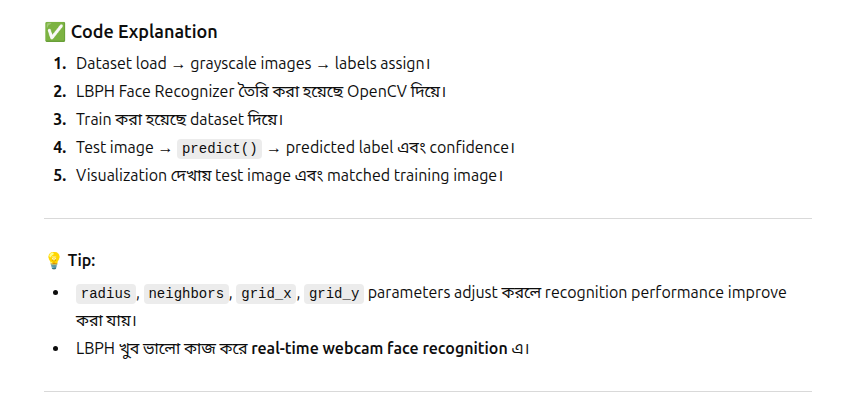

In [22]:
import cv2
import os
import numpy as np

# 1️⃣ Load and Train LBPH Recognizer
dataset_path = "../dataset/test/"
faces = []
labels = []

label_dict = {}
current_label = 0

for person_name in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person_name)
    if not os.path.isdir(person_path):
        continue
    label_dict[current_label] = person_name
    for img_name in os.listdir(person_path):
        img_path = os.path.join(person_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (100, 100))  # ✅ Fixed size
        faces.append(img)
        labels.append(current_label)
    current_label += 1

faces = np.array(faces, dtype='uint8')
labels = np.array(labels, dtype='int32')

# ✅ Train LBPH
lbph_recognizer = cv2.face.LBPHFaceRecognizer_create()
lbph_recognizer.train(faces, labels)
print("✅ LBPH Recognizer trained successfully!")

# 2️⃣ Initialize Webcam
cap = cv2.VideoCapture(0)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces_rects = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5)

    for (x, y, w, h) in faces_rects:
        face_roi = gray[y:y+h, x:x+w]
        face_roi = cv2.resize(face_roi, (100, 100))  # ✅ same as training

        label, confidence = lbph_recognizer.predict(face_roi)
        name = label_dict[label]

        # Draw rectangle + label
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(frame, f"{name} ({confidence:.0f})", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

    cv2.imshow("LBPH Face Recognition", frame)

    if cv2.waitKey(1) & 0xFF == 27:  # ESC to exit
        break

cap.release()
cv2.destroyAllWindows()

✅ LBPH Recognizer trained successfully!


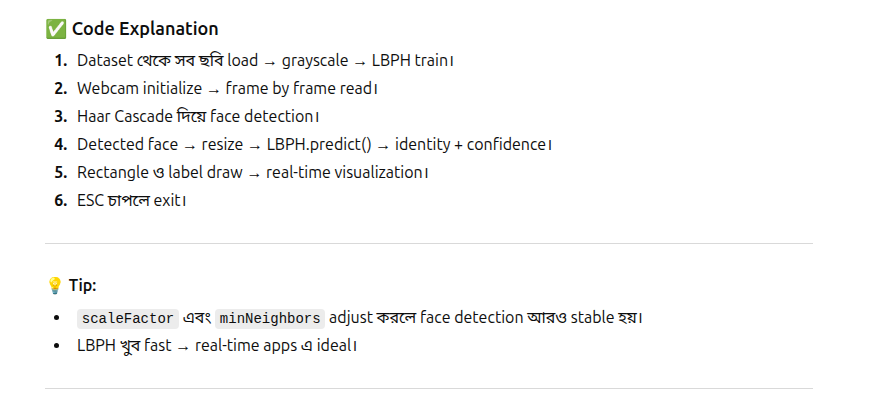